# 1. Conditions and loops

Learn to select instructions with `if`, repeat work with `for` and `while`, and inspect an accumulator after each iteration. You will distinguish missing data from zero and prevent a batch loop from running forever. Prerequisite: [Lists, tuples, sets and dictionaries](../../../01_Python_Foundations/04_lists_tuples_sets_and_dictionaries.ipynb). Allow two hours, including tracing each loop on paper before execution.

## 2. What problem does this solve?

Data-processing instructions depend on their inputs. A missing reading needs different treatment from a valid zero. A dataset of a thousand rows requires repeated work without writing a thousand copies of the same instruction. Conditions and loops express those decisions and repetitions explicitly.

In ML, these mechanisms appear in record validation, mini-batch creation, training epochs, and error analysis. A faulty boundary or early exit can change which examples influence a result. Understanding control flow is therefore necessary even when a library performs most numerical work.

## 3. Intuition and analogy

An `if` statement resembles a gate: enter a branch only when its condition is true. A `for` loop resembles checking every item on a finite list. A `while` loop resembles continuing a task until a stopping condition changes. The last pattern needs special care because a mistake can leave the stopping condition true forever.

Keep a small trace table with the current item, decision, running sum, and accepted count. It shows exactly how the final answer arises and is often more useful than staring at the final number.

## 4. Terminology

A **branch** is one path through a conditional. `elif` means test another condition if earlier branches were not selected; `else` handles the remaining case. An **iteration** is one pass through a loop body. An **iterable** supplies successive items, such as a list or `range`.

An **accumulator** combines results over iterations, such as a running total. `continue` skips the rest of the current iteration. `break` leaves the nearest enclosing loop. **Indentation** defines the body of a branch or loop. A **loop invariant** is a useful statement that stays true as the loop progresses; for example, accepted count equals the number of accepted rows seen so far.

## 5. Mathematical foundations

Let $v_i$ be a recorded quantity and $a_i$ indicate whether it satisfies our validity rule. For n records,

$$S=\sum_{i=1}^{n}a_i v_i,\qquad m=\sum_{i=1}^{n}a_i,\qquad \bar v=S/m\quad(m>0).$$

S is the accepted total in measurement units, m is the number of accepted observations, and the mean retains the measurement units. We do not literally multiply a missing value by zero in Python; we skip it before numerical arithmetic. The notation describes the valid observed contributions.

The denominator is accepted count, not all input rows. Missing or rejected rows should be counted and reported separately so that exclusion does not disappear inside a seemingly precise mean.

## 6. Hand-calculated example

Consider invented readings `[12,None,-1,18,0]`, in item counts. Assume our device permits nonnegative counts, treats `None` as missing, and flags negative values as invalid. Accepted values are 12, 18, and zero. Total is 30, count is three, and accepted mean is ten items. Two rows are excluded, for different reasons.

After the first row, total is 12 and count one. The next two rows change neither. After 18, total is 30 and count two. The valid zero leaves total at 30 but increases count to three. Dropping zero as “false” would incorrectly report a mean of 15.

## 7. Implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
readings = [12, None, -1, 18, 0]
total = 0
accepted_count = 0
missing_count = 0
invalid_count = 0
trace = []
for position, value in enumerate(readings):
    if value is None:
        missing_count += 1
        decision = 'missing'
    elif value < 0:
        invalid_count += 1
        decision = 'invalid'
    else:
        total += value
        accepted_count += 1
        decision = 'accepted'
    trace.append((position, value, decision, total, accepted_count))
assert total == 30 and accepted_count == 3
assert missing_count == invalid_count == 1

`enumerate` supplies each position together with its value. The missing test comes first because comparing `None < 0` would raise an error. Exactly one branch is selected for each row. This code assumes nonmissing readings are numeric; later validation lessons strengthen the schema.

## 8. Step-by-step output inspection

In [3]:
for row in trace:
    print('position, value, decision, running total, accepted count:', row)
accepted_mean = total / accepted_count if accepted_count > 0 else None
assert accepted_mean == 10
assert accepted_count + missing_count + invalid_count == len(readings)
print('Accepted mean:', accepted_mean, 'Excluded:', missing_count + invalid_count)

position, value, decision, running total, accepted count: (0, 12, 'accepted', 12, 1)
position, value, decision, running total, accepted count: (1, None, 'missing', 12, 1)
position, value, decision, running total, accepted count: (2, -1, 'invalid', 12, 1)
position, value, decision, running total, accepted count: (3, 18, 'accepted', 30, 2)
position, value, decision, running total, accepted count: (4, 0, 'accepted', 30, 3)
Accepted mean: 10.0 Excluded: 2


The reconciliation checks that every input row was assigned one outcome. This is stronger than checking only the final mean. A different bug might accidentally skip a row while still producing a plausible average. If no observations are accepted, we return `None` here as a stated convention rather than dividing by zero.

## 9. Library comparison

The standard library supplies reliable summation and descriptive statistics. We still have to specify which inputs are valid; a library cannot infer the device's allowed range. A second loop below builds the explicit accepted list so its contents can be inspected.

In [4]:
import math
import statistics
accepted_values = []
for value in readings:
    if value is None:
        continue
    if value < 0:
        continue
    accepted_values.append(value)
assert accepted_values == [12, 18, 0]
assert math.fsum(accepted_values) == total
assert statistics.mean(accepted_values) == accepted_mean

`continue` makes each rejection leave the current iteration early. For complicated rules, early exits can reduce nesting, but recording the reason remains essential. A blank list supplied to `statistics.mean` raises an error, so the empty case needs an explicit policy.

## 10. Visualization

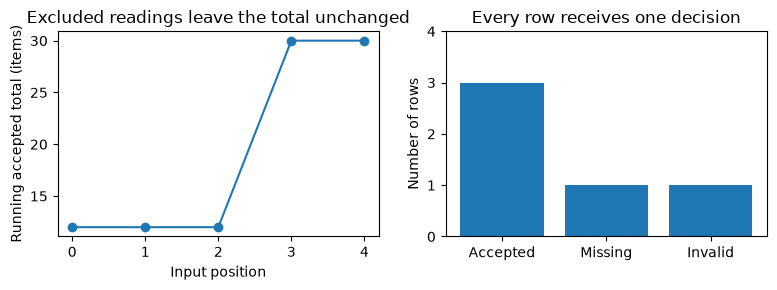

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot([row[0] for row in trace], [row[3] for row in trace], marker='o')
axes[0].set(xlabel='Input position', ylabel='Running accepted total (items)', title='Excluded readings leave the total unchanged')
axes[1].bar(['Accepted', 'Missing', 'Invalid'], [accepted_count, missing_count, invalid_count])
axes[1].set(ylabel='Number of rows', title='Every row receives one decision', ylim=(0, 4))
fig.tight_layout()
display(fig)
plt.close(fig)

The flat segment through missing and invalid rows shows that neither contributed numerically. The last valid zero also leaves total unchanged, which is why the separate accepted-count check matters. A single plotted sum cannot reveal every processing decision.

## 11. Realistic experiment: batching records

Ten examples in groups of at most four require batch sizes four, four, and two. A `while` loop can process the remaining count, but must decrease it on every iteration. We assert progress to make the stopping argument visible.

In [6]:
remaining = 10
capacity = 4
assert capacity > 0 and remaining >= 0
batch_sizes = []
while remaining > 0:
    previous = remaining
    batch_size = min(capacity, remaining)
    batch_sizes.append(batch_size)
    remaining -= batch_size
    assert 0 <= remaining < previous
assert batch_sizes == [4, 4, 2]
assert sum(batch_sizes) == 10
print('Batch sizes:', batch_sizes)

Batch sizes: [4, 4, 2]


In a training loop, one epoch usually means one traversal of the training data. It can contain several batches. This count-only example teaches iteration and stopping; it does not implement shuffling, model updates, or an entire training system.

## 12. Choices and experiments

Validity rules, empty-result behavior, and batch capacity are explicit processing settings. There are no learned parameters here. Change the rule from `value < 0` to `value <= 0` and calculate how excluding the valid zero changes the mean. Then explain why changing a rule merely to obtain a preferred mean would be poor analysis.

For loops over `range(start,stop)`, the stop is excluded. `range(3)` produces positions zero, one, and two. Test the boundary deliberately when creating batches or selecting train/test windows.

## 13. Evaluation

Check row reconciliation, accepted values, totals, and empty input. For batching, verify every example is accounted for exactly once and no batch exceeds capacity. For a `while` loop, identify a quantity that moves toward a stopping bound. A fixed maximum iteration count can also protect numerical optimization from an endlessly unmet convergence condition.

## 14. Assumptions and limitations

Excluding invalid records can introduce bias if invalidity relates to the outcome. We report counts but do not solve that statistical problem. Numeric comparisons with nonfinite floats need additional rules: `nan < 0` is false, so this simple negative-only check would not reject NaN. A production validator must check finiteness and allowed types explicitly.

## 15. Common mistakes and debugging

Do not use `if value:` to mean “a reading is present,” because zero is falsey. Do not reset an accumulator inside the loop accidentally. Do not forget to update a `while` loop's progress variable. Do not mutate a list by deleting items while iterating over it without carefully designed semantics. Trace the first few iterations before running a large dataset.

## 16. Comparison with alternatives

A plain loop is valuable for understanding state and collecting diagnostic reasons. A comprehension concisely constructs a sequence and is introduced next in the full Python path. NumPy masks and pandas filtering express many rowwise conditions efficiently. The same information rules apply regardless of syntax; vectorizing a wrong condition only makes the wrong calculation faster.

## 17. Exercises

1. **Beginner:** Trace accepted total and count for `[0,4,None,6]` using the stated rule.
2. **Beginner:** List the values produced by `range(2,5)`.
3. **Beginner:** Explain why missing and zero need different branches.
4. **Intermediate:** Write a bounded loop that stops when it first sees a negative reading, and distinguish this from skipping negatives.
5. **Intermediate:** Derive batch sizes for nine examples and capacity four, and state two reconciliation checks.
6. **Challenge:** Strengthen validation to reject nonnumeric, Boolean, nonfinite, and negative values, preserving a reason for every excluded row and returning no mean when none are valid.

## 18. Detailed solutions

1. Accepted values zero, four, and six give total ten, count three, and mean $10/3$. The missing row changes neither sum nor count.
2. Two, three, and four; five is the excluded stop.
3. Zero is an observed value that contributes to the denominator; missing data supplies no observed magnitude.
4. `break` ends the whole loop, so later positive records are not inspected. `continue` skips only the current negative record. Choose based on the intended protocol, not convenience.
5. Four, four, and one. Their sum must be nine and every batch size must be between one and four.
6. The solution below records explicit reasons. The accepted types are intentionally limited to ordinary Python int and float values for this teaching example.

In [7]:
values = [0, None, True, '4', float('nan'), float('inf'), -2, 8]
accepted = []
reasons = []
for value in values:
    if value is None:
        reasons.append('missing')
    elif type(value) not in (int, float):
        reasons.append('type')
    elif not math.isfinite(value):
        reasons.append('nonfinite')
    elif value < 0:
        reasons.append('negative')
    else:
        accepted.append(value)
        reasons.append('accepted')
answer = statistics.mean(accepted) if accepted else None
assert accepted == [0, 8] and answer == 4
assert len(reasons) == len(values)
assert reasons.count('accepted') == len(accepted) == 2
print('Validation decisions:', reasons, 'Mean:', answer)

Validation decisions: ['accepted', 'missing', 'type', 'type', 'nonfinite', 'nonfinite', 'negative', 'accepted'] Mean: 4


The final accepted-count check can be written directly without a category-counting library. For an all-invalid input, an empty accepted list would select `None`. A more general numerical API would decide whether to accept NumPy numeric scalar types as well.

## 19. Knowledge check

**What is an iteration?** One pass through a loop body. **What does continue skip?** The rest of the current iteration. **What does break end?** The nearest enclosing loop. **Why track excluded counts?** To make the denominator and selection process inspectable. **What stops a while loop safely?** Its condition eventually becomes false, supported by progress or a bound.

## 20. Interview preparation

**For versus while?** Iterate supplied items versus repeat under a condition. **Why are off-by-one errors common?** Inclusive mathematical descriptions differ from excluded Python stop positions. **What is a loop invariant?** A statement preserved through each iteration, useful for reasoning and checks. **Why can skipping bad rows bias a model?** Excluded observations may differ systematically from retained observations. **How debug a training loop?** Inspect a tiny trace, shapes, losses, counts, update order, and stopping rules before scaling up.

## 21. Summary and next steps

Control flow makes decisions and repetition explicit. Correct loops preserve counts, pairing, and stopping conditions. Continue to [Functions and parameters](../../../01_Python_Foundations/06_functions_and_parameters.ipynb) to package these calculations with clear inputs and outputs.